# Tasks:
* Remember: scale your data appropriately

* Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)

* Decide your optimization metric.

* Write down your network architecture. You can start from a fully connected, multi-layer perceptron (and then explore)

* Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning.

* Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best. Do your best now to optimize the network architecture. Be creative!

* Report on the perfomance of the network on the test set; report other metrics that have not been optimized.

A few tips:
* In scikit-learn, remember that you can utilize all availables cores on your machine with n_jobs=-1. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
* If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
* On cross validation, for scikit learn we've seen how to use GridSearchCV already. For Tensorflow, there's a really cool tool called Tensorboard

# Galaxy vs QSO

In [1]:
from pathlib import Path


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler



### Loading and inspection

In [2]:

def load_data(csv_path: Path):
    df = pd.read_csv(csv_path)
    df = df.dropna()

    # Build color features from magnitudes.
    df["u-g"] = df["u"] - df["g"]
    df["g-r"] = df["g"] - df["r"]
    df["r-i"] = df["r"] - df["i"]
    df["i-z"] = df["i"] - df["z"]

    feature_cols = ["u-g", "g-r", "r-i", "i-z"]
    X = df[feature_cols].to_numpy(dtype=float)
    y = (df["class"] == "QSO").astype(int).to_numpy()
    return X, y, feature_cols

In [3]:
csv = '..\solutions\galaxyquasar.csv'

In [4]:
X, y, feature_cols = load_data(csv)
print(f"Loaded {len(X)} objects with {X.shape[1]} features: {feature_cols}")

Loaded 50000 objects with 4 features: ['u-g', 'g-r', 'r-i', 'i-z']


## Common train / validation / test split (shared by all models)


In [5]:
# 1) Create common splits: train (60%), val (20%), test (20%)
from sklearn.model_selection import train_test_split

# Reserve a final test set (20%)
X_temp, X_common_test, y_temp, y_common_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Split remaining 80% into train (60% overall) and validation (20% overall)
X_common_train, X_common_val, y_common_train, y_common_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print('Shapes (train, val, test):', X_common_train.shape, X_common_val.shape, X_common_test.shape)

# Fit a single scaler on the training data and reuse it for all models (prevents leakage)
from sklearn.preprocessing import StandardScaler
scaler_common = StandardScaler()
X_common_train_s = scaler_common.fit_transform(X_common_train)
X_common_val_s = scaler_common.transform(X_common_val)
X_common_test_s = scaler_common.transform(X_common_test)

# Keep explicit names for later reuse
X_skl_train, X_skl_val, X_skl_test = X_common_train_s, X_common_val_s, X_common_test_s
y_skl_train, y_skl_val, y_skl_test = y_common_train, y_common_val, y_common_test

Shapes (train, val, test): (30000, 4) (10000, 4) (10000, 4)


### Scikit-learn MLP using shared split (variables prefixed with skl_)
Simple MLP trained on the common split so you can compare fairly with other frameworks.

In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

# Try to use best params from earlier grid searches if available
skl_hidden = (64, 32, 16)
skl_lr = 1e-3
skl_max_iter = 400
if 'refined_grid' in globals():
    try:
        p = refined_grid.best_params_
        skl_hidden = p.get('mlp__hidden_layer_sizes', skl_hidden)
        skl_lr = float(p.get('mlp__learning_rate_init', skl_lr))
        skl_max_iter = int(p.get('mlp__max_iter', skl_max_iter))
    except Exception:
        pass

print('skl params ->', skl_hidden, skl_lr, skl_max_iter)

skl_model = MLPClassifier(hidden_layer_sizes=skl_hidden, learning_rate_init=skl_lr, max_iter=skl_max_iter, random_state=42)
skl_model.fit(X_skl_train, y_skl_train)

skl_val_prob = skl_model.predict_proba(X_skl_val)[:, 1]
skl_val_pred = (skl_val_prob >= 0.5).astype(int)
skl_test_prob = skl_model.predict_proba(X_skl_test)[:, 1]
skl_test_pred = (skl_test_prob >= 0.5).astype(int)

print('SKL val AUC:', round(roc_auc_score(y_skl_val, skl_val_prob), 4))
print('SKL test AUC:', round(roc_auc_score(y_skl_test, skl_test_prob), 4))
print('SKL test acc:', round(accuracy_score(y_skl_test, skl_test_pred), 4))
print('SKL test confusion:')
print(confusion_matrix(y_skl_test, skl_test_pred))
print('\nSKL classification report (test):')
print(classification_report(y_skl_test, skl_test_pred, target_names=['GALAXY','QSO']))

skl params -> (64, 32, 16) 0.001 400
SKL val AUC: 0.9931
SKL test AUC: 0.9891
SKL test acc: 0.9832
SKL test confusion:
[[8511   62]
 [ 106 1321]]

SKL classification report (test):
              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99      8573
         QSO       0.96      0.93      0.94      1427

    accuracy                           0.98     10000
   macro avg       0.97      0.96      0.97     10000
weighted avg       0.98      0.98      0.98     10000



### PyTorch MLP using shared split (variables prefixed with torch_)
Small, clear network with device handling and early stopping on the common validation set.

In [8]:
import torch
import torch.nn as nn
import torch.utils.data as torchdata

# device: will use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Prepare tensors; move to device
X_torch_train = torch.tensor(X_common_train_s, dtype=torch.float32).to(device)
y_torch_train = torch.tensor(y_common_train, dtype=torch.float32).view(-1,1).to(device)
X_torch_val = torch.tensor(X_common_val_s, dtype=torch.float32).to(device)
y_torch_val = torch.tensor(y_common_val, dtype=torch.float32).view(-1,1).to(device)
X_torch_test = torch.tensor(X_common_test_s, dtype=torch.float32).to(device)
y_torch_test = torch.tensor(y_common_test, dtype=torch.float32).view(-1,1).to(device)

class TorchGalaxyQsoNet(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

torch_hidden = (64, 32, 16)
torch_lr = 1e-2
torch_epochs = 80
torch_batch = 64

torch_model = TorchGalaxyQsoNet(X_common_train_s.shape[1], torch_hidden).to(device)
optimizer = torch.optim.Adam(torch_model.parameters(), lr=torch_lr)
criterion = nn.BCEWithLogitsLoss()

train_ds = torchdata.TensorDataset(X_torch_train, y_torch_train)
train_loader = torchdata.DataLoader(train_ds, batch_size=torch_batch, shuffle=True)

# early stopping on validation AUC
best_val_auc = 0.0
patience = 10
bad = 0
best_state = None

for epoch in range(torch_epochs):
    torch_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = torch_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    # validation
    torch_model.eval()
    with torch.no_grad():
        val_logits = torch_model(X_torch_val)
        val_prob = torch.sigmoid(val_logits).view(-1).cpu().numpy()
        try:
            val_auc = roc_auc_score(y_common_val, val_prob)
        except Exception:
            val_auc = 0.0

    if epoch % 10 == 0 or epoch == torch_epochs - 1:
        print(f'Torch epoch {epoch+1}/{torch_epochs} | train loss {epoch_loss/len(train_ds):.6f} | val_auc {val_auc:.4f}')

    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        bad = 0
        best_state = {k: v.cpu().clone() for k, v in torch_model.state_dict().items()}
    else:
        bad += 1
    if bad >= patience:
        print('Torch early stopping at epoch', epoch+1)
        break

if best_state is not None:
    torch_model.load_state_dict(best_state)

# evaluate on validation and test
torch_model.eval()
with torch.no_grad():
    val_logits = torch_model(X_torch_val)
    torch_val_prob = torch.sigmoid(val_logits).view(-1).cpu().numpy()
    test_logits = torch_model(X_torch_test)
    torch_test_prob = torch.sigmoid(test_logits).view(-1).cpu().numpy()

print('Torch val AUC:', round(roc_auc_score(y_common_val, torch_val_prob), 4))
print('Torch test AUC:', round(roc_auc_score(y_common_test, torch_test_prob), 4))

Torch epoch 1/80 | train loss 0.078761 | val_auc 0.9914
Torch epoch 11/80 | train loss 0.049441 | val_auc 0.9932
Torch early stopping at epoch 16
Torch val AUC: 0.9935
Torch test AUC: 0.9932


### TensorFlow classifier (variables prefixed with tf_)
Simple dense model, logs to TensorBoard; uses the same validation set.

In [10]:
import tensorflow as tf
from tensorflow import keras
import os

tf.random.set_seed(42)

X_tf_train = X_common_train_s.astype('float32')
X_tf_val = X_common_val_s.astype('float32')
X_tf_test = X_common_test_s.astype('float32')
y_tf_train = y_common_train
y_tf_val = y_common_val
y_tf_test = y_common_test

tf_model = keras.Sequential([
    keras.layers.Input(shape=(X_tf_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
tf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

logdir = os.path.join('logs', 'tf_run')
tensorboard_cb = keras.callbacks.TensorBoard(log_dir=logdir)
early_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tf_history = tf_model.fit(X_tf_train, y_tf_train, validation_data=(X_tf_val, y_tf_val), epochs=100, batch_size=64, callbacks=[early_cb], verbose=1)

tf_val_prob = tf_model.predict(X_tf_val).ravel()
tf_test_prob = tf_model.predict(X_tf_test).ravel()

print('TF val AUC:', round(roc_auc_score(y_tf_val, tf_val_prob), 4))
print('TF test AUC:', round(roc_auc_score(y_tf_test, tf_test_prob), 4))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9766 - loss: 0.1382 - val_accuracy: 0.9810 - val_loss: 0.0683
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9843 - loss: 0.0698 - val_accuracy: 0.9831 - val_loss: 0.0637
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9848 - loss: 0.0641 - val_accuracy: 0.9838 - val_loss: 0.0611
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.0597 - val_accuracy: 0.9841 - val_loss: 0.0596
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9851 - loss: 0.0573 - val_accuracy: 0.9843 - val_loss: 0.0587
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9854 - loss: 0.0555 - val_accuracy: 0.9841 - val_loss: 0.0582
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9857 - loss: 0.0542 - val_accuracy: 0.9843 - val_loss: 0.0577
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9858 - loss: 0.0532 - val_accu

### Model comparison and cross-correlation on the shared validation set
We compute validation metrics and Pearson correlations between models' predicted probabilities.

skl | val AUC: 0.9931 | val acc: 0.9856
torch | val AUC: 0.9935 | val acc: 0.9856
tf | val AUC: 0.9933 | val acc: 0.9852

Pairwise Pearson correlation (validation probs):
skl vs skl: 1.000  skl vs torch: 0.990  skl vs tf: 0.996  
torch vs skl: 0.990  torch vs torch: 1.000  torch vs tf: 0.995  
tf vs skl: 0.996  tf vs torch: 0.995  tf vs tf: 1.000  


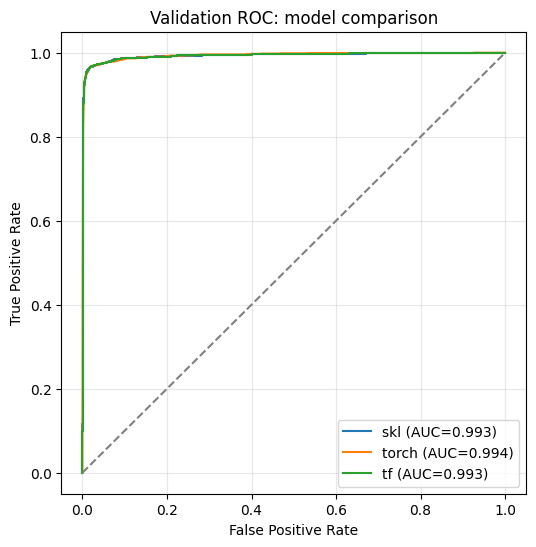

In [11]:
import numpy as np
import matplotlib.pyplot as plt

probs_dict = {
    'skl': skl_val_prob,
    'torch': torch_val_prob,
    'tf': tf_val_prob
}

for name, p in probs_dict.items():
    pred = (p >= 0.5).astype(int)
    auc = roc_auc_score(y_common_val, p)
    acc = accuracy_score(y_common_val, pred)
    print(f"{name} | val AUC: {auc:.4f} | val acc: {acc:.4f}")

names = list(probs_dict.keys())
corr_mat = np.corrcoef([probs_dict[n] for n in names])
print('\nPairwise Pearson correlation (validation probs):')
for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        print(f"{ni} vs {nj}: {corr_mat[i,j]:.3f}", end='  ')
    print()

plt.figure(figsize=(6,6))
for name, p in probs_dict.items():
    fpr, tpr, _ = roc_curve(y_common_val, p)
    auc = roc_auc_score(y_common_val, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Validation ROC: model comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

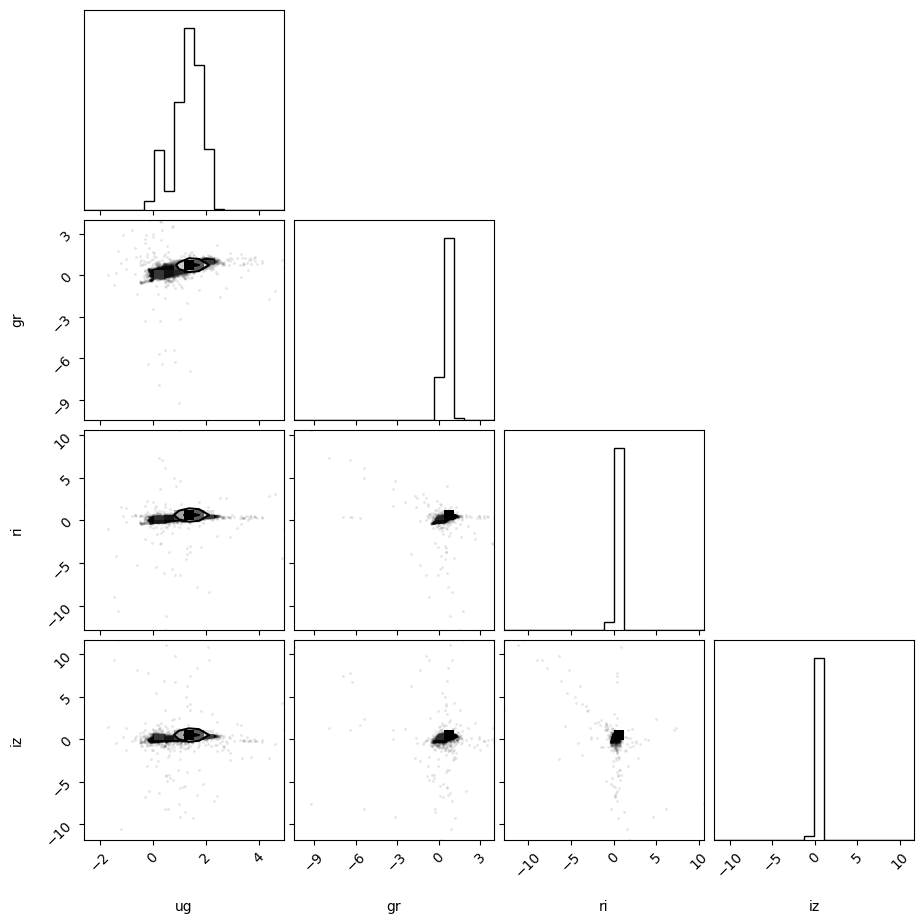

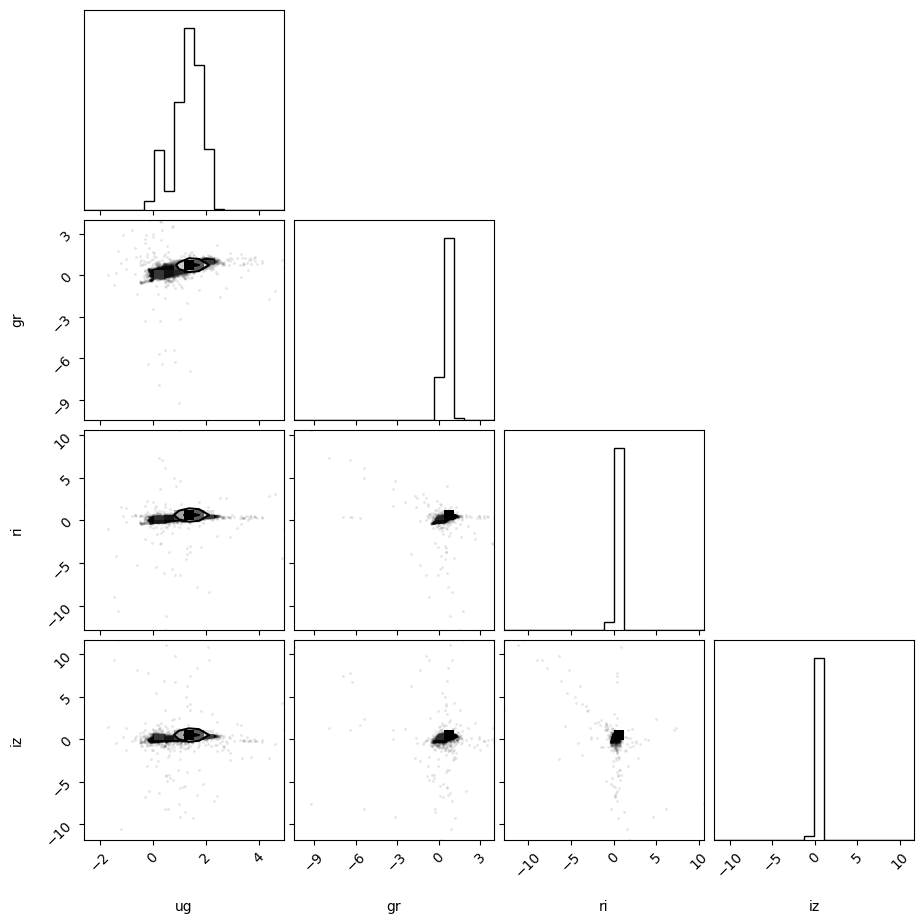

In [7]:
import corner

corner.corner(X, labels=['ug', 'gr', 'ri', 'iz'])

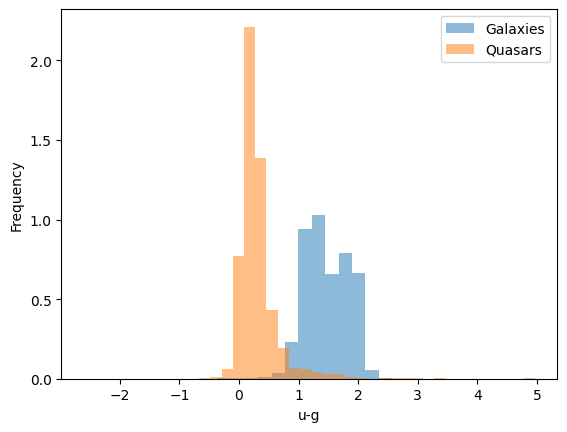

In [11]:
plt.hist(X[y == 0, 0], bins=30, alpha=0.5, label='Galaxies', density='True')
plt.hist(X[y == 1, 0], bins=30, alpha=0.5, label='Quasars', density='True')
plt.xlabel('u-g')
plt.ylabel('Frequency')
plt.legend()
plt.show()


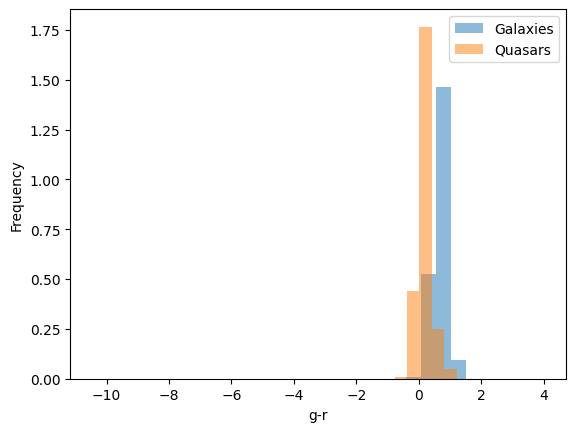

In [12]:
plt.hist(X[y == 0, 1], bins=30, alpha=0.5, label='Galaxies', density='True')
plt.hist(X[y == 1, 1], bins=30, alpha=0.5, label='Quasars', density='True')
plt.xlabel('g-r')
plt.ylabel('Frequency')
plt.legend()
plt.show()

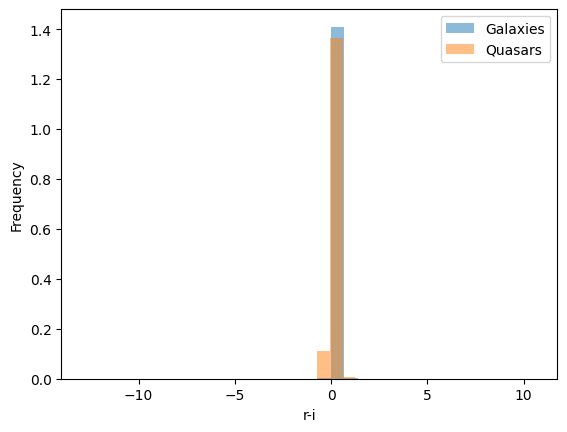

In [13]:
plt.hist(X[y == 0, 2], bins=30, alpha=0.5, label='Galaxies', density='True')
plt.hist(X[y == 1, 2], bins=30, alpha=0.5, label='Quasars', density='True')
plt.xlabel('r-i')
plt.ylabel('Frequency')
plt.legend()
plt.show()

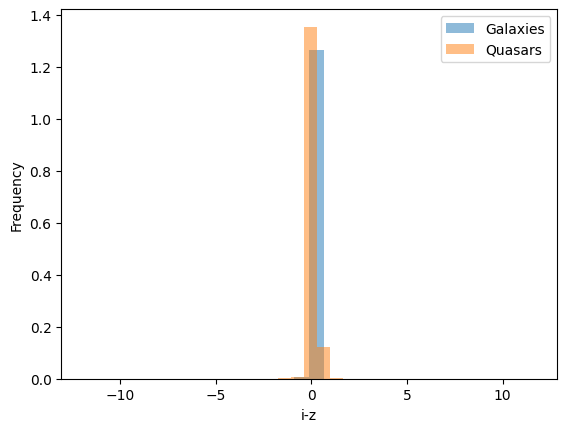

In [14]:
plt.hist(X[y == 0, 3], bins=30, alpha=0.5, label='Galaxies', density='True')
plt.hist(X[y == 1, 3], bins=30, alpha=0.5, label='Quasars', density='True')
plt.xlabel('i-z')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Simple MLP

In [5]:
def train_model_MLP(X, y, hidden_layers=(32, 16), max_iter=400, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers, # number of neurons in each hidden layer
        activation="relu", # non-linear activation function
        solver="adam", # optimization algorithm
        alpha=1e-4, #prevents overfitting
        max_iter=max_iter, # maximum number of iterations
        random_state=random_state,
    )
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["GALAXY", "QSO"])

    # Probability-based metrics for the positive class (QSO).
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, thresh  = roc_curve(y_test, y_prob)

    print("Accuracy:", round(acc, 4))
    print("ROC AUC:", round(roc_auc, 4))
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(report)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"MLP (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve for galaxy vs QSO classifier")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return scaler, model, (X_train_scaled, X_test_scaled, y_train, y_test)

Accuracy: 0.9853
ROC AUC: 0.9899
Confusion matrix:
[[8521   52]
 [  95 1332]]

Classification report:
              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99      8573
         QSO       0.96      0.93      0.95      1427

    accuracy                           0.99     10000
   macro avg       0.98      0.96      0.97     10000
weighted avg       0.99      0.99      0.99     10000



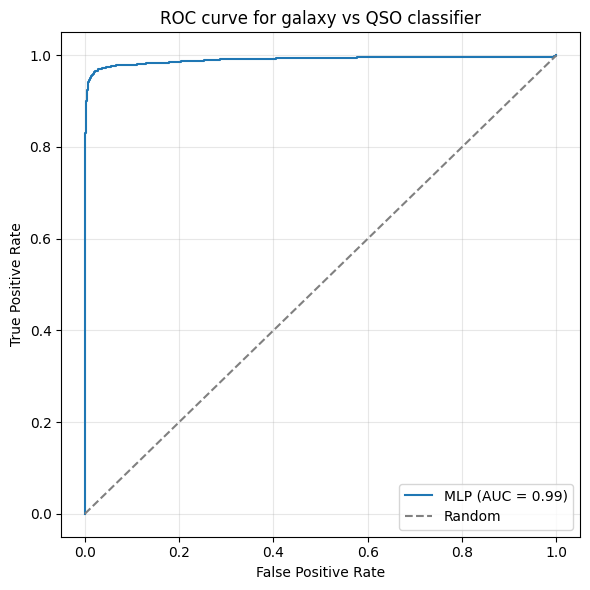

In [ ]:
scaler, model, _ = train_model_MLP(X, y)#, hidden_layers=tuple(args.hidden), max_iter=args.max_iter)

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(max_iter=400, random_state=42)),
    ]
)

param_grid = {
    "mlp__hidden_layer_sizes": [(32, 16), (64, 32), (64, 32, 16)],
    "mlp__alpha": [1e-4, 1e-3],
    "mlp__learning_rate_init": [1e-3, 1e-2],
    "mlp__activation": ["relu"],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2,
)

grid.fit(X_train_full, y_train_full)

print("Best params:", grid.best_params_)
print("Best CV ROC AUC:", round(grid.best_score_, 4))

model = grid.best_estimator_

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["GALAXY", "QSO"]))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64, 32, 16), 'mlp__learning_rate_init': 0.01}
Best CV ROC AUC: 0.9934
Test accuracy: 0.9848
Test ROC AUC: 0.9899
Confusion matrix:
[[8526   47]
 [ 105 1322]]

              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99      8573
         QSO       0.97      0.93      0.95      1427

    accuracy                           0.98     10000
   macro avg       0.98      0.96      0.97     10000
weighted avg       0.98      0.98      0.98     10000



In [19]:
print("Current best params:", grid.best_params_)
print("Current best CV ROC AUC:", round(grid.best_score_, 4))

refined_param_grid = {
    "mlp__hidden_layer_sizes": [(64, 32, 16), (128, 64, 32), (64, 32)],
    "mlp__alpha": [5e-4, 1e-3, 2e-3],
    "mlp__learning_rate_init": [5e-3, 1e-2],
    "mlp__early_stopping": [True],
    "mlp__tol": [1e-4, 1e-5],
    "mlp__max_iter": [500],
}

refined_grid = GridSearchCV(
    pipeline,
    refined_param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2,
)

refined_grid.fit(X_train_full, y_train_full)

print("Refined best params:", refined_grid.best_params_)
print("Refined best CV ROC AUC:", round(refined_grid.best_score_, 4))

best_model = refined_grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["GALAXY", "QSO"]))

Current best params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64, 32, 16), 'mlp__learning_rate_init': 0.01}
Current best CV ROC AUC: 0.9934
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Refined best params: {'mlp__alpha': 0.0005, 'mlp__early_stopping': True, 'mlp__hidden_layer_sizes': (128, 64, 32), 'mlp__learning_rate_init': 0.005, 'mlp__max_iter': 500, 'mlp__tol': 0.0001}
Refined best CV ROC AUC: 0.9935
Test accuracy: 0.9833
Test ROC AUC: 0.9927
Confusion matrix:
[[8500   73]
 [  94 1333]]

              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99      8573
         QSO       0.95      0.93      0.94      1427

    accuracy                           0.98     10000
   macro avg       0.97      0.96      0.97     10000
weighted avg       0.98      0.98      0.98     10000



# Torch

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as torchdata

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)

In [21]:
# split data into 9:1 train:test
dataset = torchdata.TensorDataset(torch.tensor(X_scaled),
                                  torch.tensor(y).view(-1, 1))
trainnum = X_scaled.shape[0] // 10 * 9
traindata, testdata = torchdata.random_split(dataset, 
                                             [trainnum, X_scaled.shape[0] - trainnum])
traindataloader = torchdata.DataLoader(traindata, 
                                       batch_size=128, 
                                       shuffle=True)

In [22]:
def train_NN(
    X,
    y,
    hidden_layers=(32, 16),
    lr=1e-2,
    epochs=80,
    batch_size=128,
    random_state=42,
):
    torch.manual_seed(random_state)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    class GalaxyQsoNet(nn.Module):
        def __init__(self, input_dim, hidden_layers):
            super().__init__()
            layers = []
            prev = input_dim
            for h in hidden_layers:
                layers.append(nn.Linear(prev, h))
                layers.append(nn.ReLU())
                prev = h
            layers.append(nn.Linear(prev, 1))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)

    model = GalaxyQsoNet(X_train.shape[1], hidden_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    train_dataset = torchdata.TensorDataset(X_train_t, y_train_t)
    train_loader = torchdata.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, drop_last=False
    )

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch + 1}/{epochs}, train loss = {epoch_loss / len(train_dataset):.5f}")

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)
        y_prob = torch.sigmoid(logits).view(-1).cpu().numpy()
        y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["GALAXY", "QSO"])
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    print("Accuracy:", round(acc, 4))
    print("ROC AUC:", round(roc_auc, 4))
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(report)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"Torch MLP (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve for galaxy vs QSO classifier")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return scaler, model, (X_train_scaled, X_test_scaled, y_train, y_test)

Epoch 1/80, train loss = 0.09309
Epoch 11/80, train loss = 0.04937
Epoch 21/80, train loss = 0.04737
Epoch 31/80, train loss = 0.04669
Epoch 41/80, train loss = 0.04595
Epoch 51/80, train loss = 0.04525
Epoch 61/80, train loss = 0.04444
Epoch 71/80, train loss = 0.04408
Epoch 80/80, train loss = 0.04396
Accuracy: 0.9827
ROC AUC: 0.9896
Confusion matrix:
[[8498   75]
 [  98 1329]]

Classification report:
              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99      8573
         QSO       0.95      0.93      0.94      1427

    accuracy                           0.98     10000
   macro avg       0.97      0.96      0.96     10000
weighted avg       0.98      0.98      0.98     10000



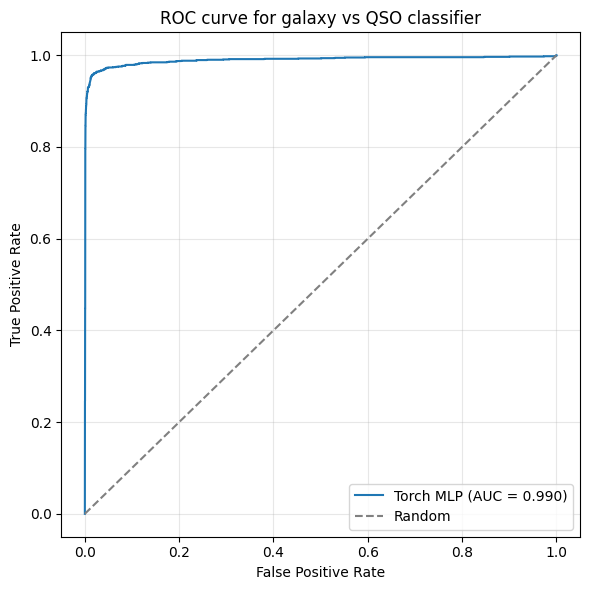

In [23]:
model = train_NN(X, y)

# Tensorflow

In [6]:
import tensorflow as tf

In [7]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (30000, 4) (30000,)
Validation: (10000, 4) (10000,)
Test: (10000, 4) (10000,)


In [8]:
# Need to reshape for CNN
X_train = X_train[:, :, np.newaxis]
X_val = X_val[:, :, np.newaxis]
X_test = X_test[:, :, np.newaxis]

print(len(X_train))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

30000
(30000, 4, 1)
(10000, 4, 1)
(10000, 4, 1)


In [9]:
from tensorflow import keras

In [10]:
keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)

In [13]:
#### This may take a while! Hopefully no more than 5 minutes for 1 epoch.

model = keras.models.Sequential([
    keras.layers.InputLayer(shape=(4, 1)),
    keras.layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation="relu", padding="same"),
    keras.layers.Conv1D(128, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(256, 3, activation="relu", padding="same"),
    keras.layers.Conv1D(256, 3, activation="relu", padding="same"),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(units=128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=2, activation="softmax"),
])
print(model.summary())
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=1, validation_data=(X_val, y_val))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410,946 (1.57 MB)

 Trainable params: 410,946 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

None
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9786 - loss: 0.0900 - val_accuracy: 0.9822 - val_loss: 0.0762


In [17]:
X_new = X_test[:3]
y_proba = model.predict(X_new).round(2)
print(y_proba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[0.28 0.72]
 [0.06 0.94]
 [0.05 0.95]]


In [15]:
y_pred = np.argmax(model.predict(X_new), axis=-1)
print(y_pred)
class_names = ["GALAXY", "QSO"]
print(np.array(class_names)[y_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[1 1 1]
['QSO' 'QSO' 'QSO']


# Torch classifier (replaces Autoencoder section)

Using hidden layers = (64, 32, 16) lr = 0.01 epochs = 80
Epoch 1/80, loss = 0.092892, val_auc = 0.9914
Epoch 11/80, loss = 0.049142, val_auc = 0.9933
Early stopping.
Accuracy: 0.9833
ROC AUC: 0.9939
Confusion matrix:
[[8528   45]
 [ 122 1305]]

              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99      8573
         QSO       0.97      0.91      0.94      1427

    accuracy                           0.98     10000
   macro avg       0.98      0.95      0.97     10000
weighted avg       0.98      0.98      0.98     10000



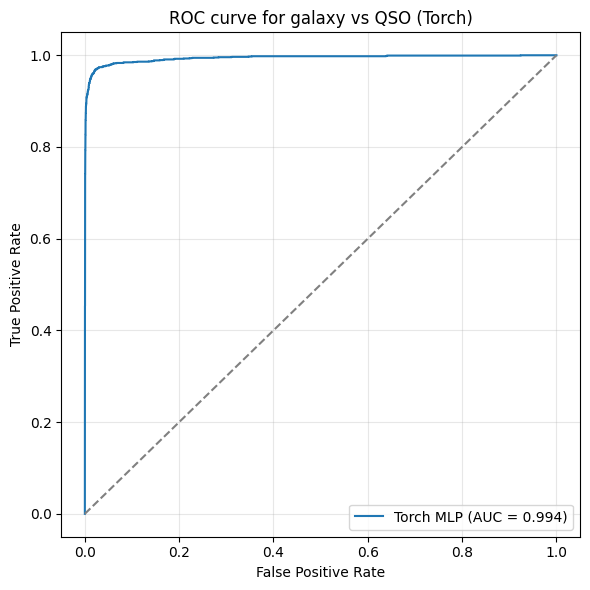

['galaxy_qso_torch_scaler.joblib']

In [24]:
# Build and train a PyTorch classifier using best hyperparameters
import joblib

# Try to extract best hyperparameters from the earlier GridSearchCV runs
hidden_layers = None
lr = 1e-2
epochs = 80
batch_size = 128

if 'refined_grid' in globals():
    try:
        p = refined_grid.best_params_
        hidden_layers = p.get('mlp__hidden_layer_sizes', None)
        lr = float(p.get('mlp__learning_rate_init', lr))
        epochs = int(p.get('mlp__max_iter', epochs))
    except Exception:
        pass
elif 'grid' in globals():
    try:
        p = grid.best_params_
        hidden_layers = p.get('mlp__hidden_layer_sizes', None)
        lr = float(p.get('mlp__learning_rate_init', lr))
    except Exception:
        pass

if hidden_layers is None:
    hidden_layers = (64, 32, 16)

print('Using hidden layers =', hidden_layers, 'lr =', lr, 'epochs =', epochs)

# Prepare train/test sets (reuse earlier splits if present)
if 'X_train_full' in globals() and 'y_train_full' in globals() and 'X_test' in globals() and 'y_test' in globals():
    X_tr = X_train_full
    y_tr = y_train_full
else:
    X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler_torch = StandardScaler()
X_tr_scaled = scaler_torch.fit_transform(X_tr)
X_test_scaled = scaler_torch.transform(X_test)

X_tr_t = torch.tensor(X_tr_scaled, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_dataset = torchdata.TensorDataset(X_tr_t, y_tr_t)
train_loader = torchdata.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

class GalaxyQsoNet(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model_torch = GalaxyQsoNet(X_tr.shape[1], hidden_layers)
optimizer = torch.optim.Adam(model_torch.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss()

# Training loop
best_val_auc = 0.0
patience = 10
bad = 0
for epoch in range(epochs):
    model_torch.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model_torch(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    # evaluate on test set each epoch (small dataset)
    model_torch.eval()
    with torch.no_grad():
        logits = model_torch(X_test_t)
        y_prob = torch.sigmoid(logits).view(-1).cpu().numpy()
        y_pred = (y_prob >= 0.5).astype(int)
        try:
            val_auc = roc_auc_score(y_test, y_prob)
        except Exception:
            val_auc = 0.0

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f'Epoch {epoch+1}/{epochs}, loss = {running_loss/len(train_dataset):.6f}, val_auc = {val_auc:.4f}')

    # simple early stopping on ROC AUC
    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        bad = 0
        best_state = {k: v.cpu().clone() for k, v in model_torch.state_dict().items()}
    else:
        bad += 1
    if bad >= patience:
        print('Early stopping.')
        break

# load best state
if 'best_state' in locals():
    model_torch.load_state_dict(best_state)

# Final evaluation
model_torch.eval()
with torch.no_grad():
    logits = model_torch(X_test_t)
    y_prob = torch.sigmoid(logits).view(-1).cpu().numpy()
    y_pred = (y_prob >= 0.5).astype(int)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
try:
    print('ROC AUC:', round(roc_auc_score(y_test, y_prob), 4))
except Exception:
    pass
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['GALAXY', 'QSO']))

# Plot ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Torch MLP (AUC = {roc_auc_score(y_test, y_prob):.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for galaxy vs QSO (Torch)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save model and scaler
torch.save(model_torch.state_dict(), 'galaxy_qso_torch_model.pth')
joblib.dump(scaler_torch, 'galaxy_qso_torch_scaler.joblib')

In [25]:
# Quick inference example on a few test samples
idx = np.random.choice(len(X_test_scaled), size=5, replace=False)
X_sample = X_test_scaled[idx]
y_sample = y_test[idx]
X_sample_t = torch.tensor(X_sample, dtype=torch.float32)
model_torch.eval()
with torch.no_grad():
    logits = model_torch(X_sample_t)
    probs = torch.sigmoid(logits).view(-1).cpu().numpy().round(3)
    preds = (probs >= 0.5).astype(int)

print('probs:', probs)
print('preds:', preds)
print('true :', y_sample)

probs: [0.976 0.001 0.023 0.001 0.132]
preds: [1 0 0 0 0]
true : [1 0 0 0 0]
